In [20]:
# =========================================================
# --- 0. Import bibliotek ---
# =========================================================
#pip install numpy
#pip install matplotlib
#pip install keras
#pip install tensorflow
import numpy as np
import matplotlib.pyplot as plt
import datetime

from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import (          #warstwy do budowy sieci
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Flatten,
    Dense,
    Dropout
)
from keras.optimizers import Adam       #optymalizator Adam
from keras.utils import to_categorical  #one-hot encoding -> zamiast liczby oznaczajacej klase, jest vektor 0 i 1, latwiejsze do pracy
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Etykieta przykładowego obrazu: [6]


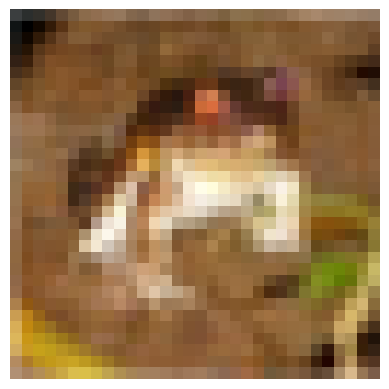

In [21]:
# =========================================================
# --- 1. Importowanie danych CIFAR10 ---
# =========================================================
# Wczytanie zbioru danych CIFAR10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Wyświetlenie przykładowego obrazu (opcjonalne)
print("Etykieta przykładowego obrazu:", y_train[0])
plt.imshow(x_train[0])
plt.axis('off')
plt.show()

w liniach x_train, x_test sa normalizowane, wartosci RGB sa splaszczane przez 255 do skali szarosci zeby gradient dzialal optymalniej i uczenie bylo szybsze



linijka 8:
one-hot encoding -> wszystkie klasy sa zbijane w tablice, jest 10 roznych klas obrazkow (class_names), wiec liczba klas bedzie rowna liczbie nazw w klasach
teraz odwolujac sie do klasy nie bedziemy musieli pamietac jaki numer ma dla szybszego przetwarzania, wystarczy w vektorze oznaczyc ja odpowiednio przez 0 i 1

In [22]:
# =========================================================
# --- 2. Wstępne przetwarzanie danych ---
# =========================================================
# Normalizacja do zakresu [0,1] i dodanie kanału (H,W,1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# One-hot encoding etykiet
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# lista nazw klas CIFAR-10 (użyteczna w wyświetleniach)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

zbudowany model z warstwami:

- Input: obrazki wejsciowe RGB 32x32
- Blok 1:
    - Conv2D: warstwa konvolucyjna, sciskanie calego obrazu do minimum zeby potem latwiej bylo zastosowac filtr, wykrywanie np krawedzi i faktur
        - uzywanie "relu" bo jest szybka, prosta i skuteczna oraz zapobiega zanikaniu gradientu
    - BatchNormalization: normalizuje aktywacje -> utrzymuje srednia blisko 0 i wariancje blisko 1 oraz stabilizuje i przyspiesza trening:
        - gradienty nie skacza ani w gore ani w dol, sa stopniowe
        - siec moze uczyc sie przez to przy wiekszym learning rate
        - zmniejsza wrazliwosc na poczatkowe wagi
        - wprowadza "szum", sprawia ze siec sie nie "przeucza"
    - Activation: oddzielnie bo BatchNormalization powinna najpirw znormalizowac wartosci z Conv2D a potem dopiero wyciszac wartosci ujemne
    - MaxPooling2D: zmniejszenie rozmiaru cech zbey zredukowac liczbe parametrow i zmniejszyc overfitting (przeuczenie)
    - Dropout: losowo wylacza czesc neuronow w czasie treningu zeby zmniejszyc overfitting i stworzyc bardziej ogolne reprezentacje, we wczesnych warstwach mala wartosc -. 0,1 odpowiada 10% neuronow
- Blok 2:
    - blok robi praktycznie to samo co blok 1 ale skupia sie na wiekszych filtrach (zamiast szukac krawedzi to bedzie szukal np kół dla samochodow)
- Blok 3:
    - Flatten: zamienia mape cech w jeden vektor zeby warstwa Dense mogla zaklasyfikowac obraz
    - Dense(64,'relu'): warstwa gesta, mozg, uczy sie kombinacji cech wykrytych przez Conv2D
    - BatchNormalization: znow normalizacja danych dla stabilniejszego gradientu
    - Activation: aktywacja tak jak w poprzednich blokach
    - Dropout(0,5): celowo silny dropout zeby warstwa dense ktora jest bardzo gesta i ma wiele parametrow nie rpzeuczyla sie
    - Dense(10,'softmax'): wyjscie modelu, vektor z wybrana klasa na podstawie softmax, ktory oblicza jaka jest szansa na ktorakolwiek z klas (oblicza prawdopodobienstwo na podstawie kombinacji cech wykrytych w dense poprzednim)
        - np vektor to: [0.01, 0.08, 0.02, 0.80, 0.03, 0.02, 0.01, 0.01, 0.01, 0.01], odpowiedz to: [0,0,0,1,0,0,0,0,0,0], wiec klasa: 'cat'

In [23]:
# =========================================================
# --- 3. Definicja modelu sieci neuronowej ---
# =========================================================
input_shape = (32, 32, 3)  # CIFAR-10 to 32x32 RGB

#todo opisac co siedzieje po kolei
model = Sequential([
    Input(shape=input_shape),

    #---------
    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    Dropout(0.1),#todo opisac co robi dropout

    #---------
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    Dropout(0.2),

    #---------

    #siec gesta
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

Zmiana: optimizer = Adam (learing_rate =  1e-2) na learning_rate = 1e-3 -> to zmniejsza niestabilnosc walidacji, program nie "skacze" po wynikach tylko przechodzi powoli

Adam -> najlepszy optymalizator, umozliwia gradientowi chwilowe cofniecie sie zeby potem moc znalezc jeszcze lepszy wynik (normalnie program zatrzymalby sie w momencie wzrastania gradientu albo po paru razach bez poprawy (petience))

In [24]:
# =========================================================
# --- 4. Kompilacja modelu ---
# =========================================================
# Optymalizator Adam, funkcja straty categorical_crossentropy, metryka accuracy
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',            #funkcja straty categorical_clossentropy -> stosowana przy klasyfikacji wieloklasowej,
                                                #ektykietach typu one-hot i przy ostatniej warstwie softmax
    metrics=['accuracy']
)

# Wyświetlenie podsumowania modelu
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,994 (2.08 MB)

 Trainable params: 545,546 (2.08 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
# =========================================================
# --- 5. Trenowanie modelu ---
# =========================================================
es = EarlyStopping(           #zatrzymuje kiedy dokaldnosc walidacji nie poprawia sie przez <patience> epok
    monitor='val_loss',       # metryka, którą obserwujemy (np. val_loss, val_accuracy)
    patience=5,               # liczba epok bez poprawy, po których zatrzymujemy trening
    min_delta=1e-5,           # minimalna wymagana zmiana, by uznać, że jest „poprawa”
    mode='min',               # 'min' jeśli monitorujemy straty, 'max' jeśli dokładność
    restore_best_weights=True
)
rlp = ReduceLROnPlateau(    #jezeli uczenie nie poprawilo sie przez ostatnie 6 epok,
                            # mdoel wraca do ostatniego minimum lokalnego
    monitor='val_loss',   # metryka do obserwacji
    factor=0.5,           # ile razy zmniejszyć LR (tu: o połowę)
    patience=3,           # liczba epok bez poprawy przed zmniejszeniem LR, rlp.patience < es.patience
    min_delta=1e-5,       # próg czułości jak wyżej
    min_lr=1e-5,          # dolna granica learning rate
    mode='min',           # 'min' dla strat, 'max' dla dokładności
)

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=64,
    epochs=50,
    validation_data=(x_test, y_test_cat),
    callbacks=[es, rlp],
    verbose=1
)

# Data skończenia treningu - timestamp - znacznik do zapisywania plików
ts = datetime.datetime.now().strftime("_%Y%m%d_%H%M")

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3977 - loss: 1.7547 - val_accuracy: 0.5981 - val_loss: 1.1390 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5938 - loss: 1.1396 - val_accuracy: 0.6470 - val_loss: 0.9979 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6439 - loss: 1.0074 - val_accuracy: 0.6160 - val_loss: 1.0685 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6737 - loss: 0.9272 - val_accuracy: 0.4791 - val_loss: 1.6595 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6975 - loss: 0.8722 - val_accuracy: 0.6572 - val_loss: 0.9730 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7095 - loss: 0.8343 - val_accuracy: 0.7059 - val_loss: 0.8392 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7247 - loss: 0.7891 

In [26]:
# =========================================================
# --- 6. Ewaluacja modelu ---
# =========================================================
loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print('Dokładność na zbiorze testowym:', f"{accuracy:.2f}")
print('Strata na zbiorze testowym:', f"{loss:.2f}")

Dokładność na zbiorze testowym: 0.78
Strata na zbiorze testowym: 0.63


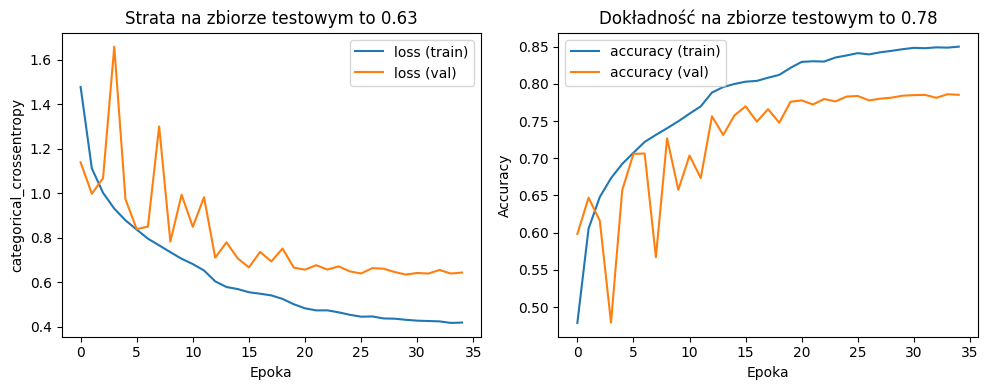

In [27]:
# =========================================================
# --- 7. Wizualizacja przebiegu treningu (loss) ---
# =========================================================
fig_loss_acc = plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss (train)')
plt.plot(history.history['val_loss'], label='loss (val)')
plt.xlabel('Epoka')
plt.ylabel('categorical_crossentropy')
plt.title(f'Strata na zbiorze testowym to {loss:.2f}')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy (train)')
plt.plot(history.history['val_accuracy'], label='accuracy (val)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.title(f"Dokładność na zbiorze testowym to {accuracy:.2f}")
plt.legend()
plt.tight_layout()

# Zapis wykresu
#loss_acc_path = os.path.join(base_export_dir, f'training_loss_accuracy{ts}.png')
#fig_loss_acc.savefig(loss_acc_path)
#print("Zapisano wykres loss/accuracy ->", loss_acc_path)

plt.show()

Oś Ox -> predykcja modelu

Oś Oy -> prawdziwa klasa

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


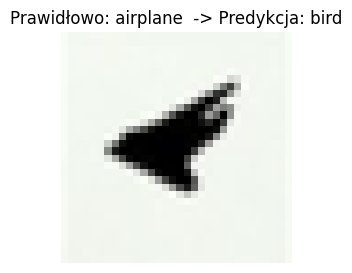

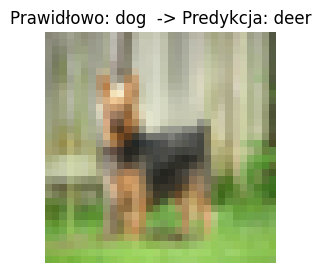

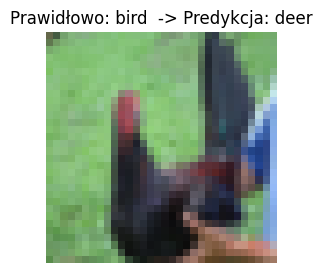

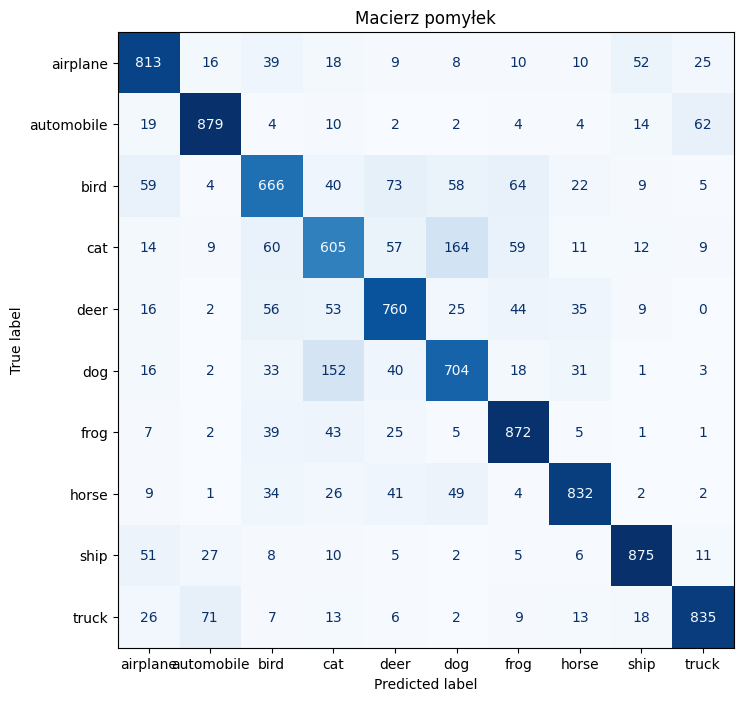

In [28]:
# =========================================================
# --- 8. Wizualizacja błędnych klasyfikacji i macierz pomyłek ---
# =========================================================
# Predykcje (etykiety)
pred_probs = model.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)  # lub po prostu y_test

# Indeksy błędnych klasyfikacji
incorrect_indices = np.nonzero(pred_labels != true_labels)[0]

# Wyświetlenie kilku błędnych przykładów
n_show = min(3, len(incorrect_indices))
for i in range(n_show):
    idx = incorrect_indices[i]
    plt.figure(figsize=(3,3))
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Prawidłowo: {class_names[true_labels[idx]]}  -> Predykcja: {class_names[pred_labels[idx]]}")
    plt.axis('off')
    plt.show()

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig_cm, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Macierz pomyłek')
# Zapis wykresu
#loss_acc_path = os.path.join(base_export_dir, f'confusion_matrix{ts}.png')
#fig_cm.savefig(loss_acc_path)
#print("Zapisano macierz pomyłek ->", loss_acc_path)
plt.show()
